In [2]:
import numpy as np
import pandas as pd

In [3]:
TRAIN_PATH = "../data/raw/CMAPSSData/train_FD001.txt"

In [4]:
df = pd.read_csv(TRAIN_PATH,sep=r"\s+",header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
df.shape

(20631, 26)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20631 non-null  int64  
 1   1       20631 non-null  int64  
 2   2       20631 non-null  float64
 3   3       20631 non-null  float64
 4   4       20631 non-null  float64
 5   5       20631 non-null  float64
 6   6       20631 non-null  float64
 7   7       20631 non-null  float64
 8   8       20631 non-null  float64
 9   9       20631 non-null  float64
 10  10      20631 non-null  float64
 11  11      20631 non-null  float64
 12  12      20631 non-null  float64
 13  13      20631 non-null  float64
 14  14      20631 non-null  float64
 15  15      20631 non-null  float64
 16  16      20631 non-null  float64
 17  17      20631 non-null  float64
 18  18      20631 non-null  float64
 19  19      20631 non-null  float64
 20  20      20631 non-null  float64
 21  21      20631 non-null  int64  
 22

In [8]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [9]:
column_names = (
    ["engine_id", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

In [10]:
len(column_names)

26

In [11]:
df.columns = column_names

In [12]:
df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [13]:
max_cycle_per_engine = df.groupby("engine_id")["cycle"].max()

In [14]:
max_cycle_per_engine.head()

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

In [15]:
df["max_cycle"] = df.groupby("engine_id")["cycle"].transform("max")

In [16]:
df["RUL"] = df["max_cycle"] - df["cycle"]

In [17]:
df[df["engine_id"] == 1][
    ["engine_id", "cycle", "max_cycle", "RUL"]
].head(10)

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [19]:
df.isnull().sum()

engine_id       0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
max_cycle       0
RUL             0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

constant_columns

['op_setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19']

In [22]:
df = df.drop(columns=constant_columns)

In [23]:
df.shape

(20631, 21)

In [24]:
sensor_columns = [
    col for col in df.columns
    if col.startswith("sensor_")
]

df[sensor_columns].var().sort_values()

sensor_6       0.000002
sensor_15      0.001407
sensor_8       0.005039
sensor_13      0.005172
sensor_21      0.011718
sensor_20      0.032669
sensor_11      0.071336
sensor_2       0.250053
sensor_12      0.543985
sensor_7       0.783388
sensor_17      2.398667
sensor_3      37.590994
sensor_4      81.010886
sensor_14    363.900490
sensor_9     487.653568
dtype: float64

In [25]:
engine_1 = df[df["engine_id"] == 1]

In [26]:
engine_1[["cycle", "RUL"]].head()

,cycle,RUL
0,1,191
1,2,190
2,3,189
3,4,188
4,5,187


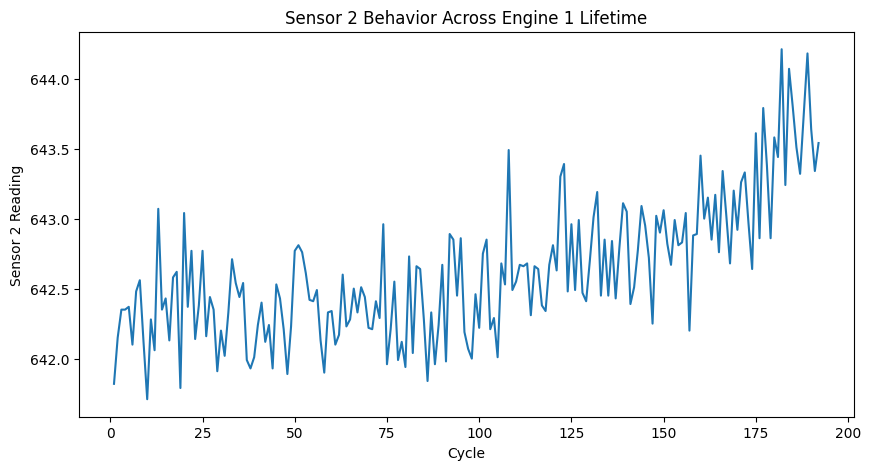

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["sensor_2"]
)

plt.xlabel("Cycle")
plt.ylabel("Sensor 2 Reading")
plt.title("Sensor 2 Behavior Across Engine 1 Lifetime")

plt.show()

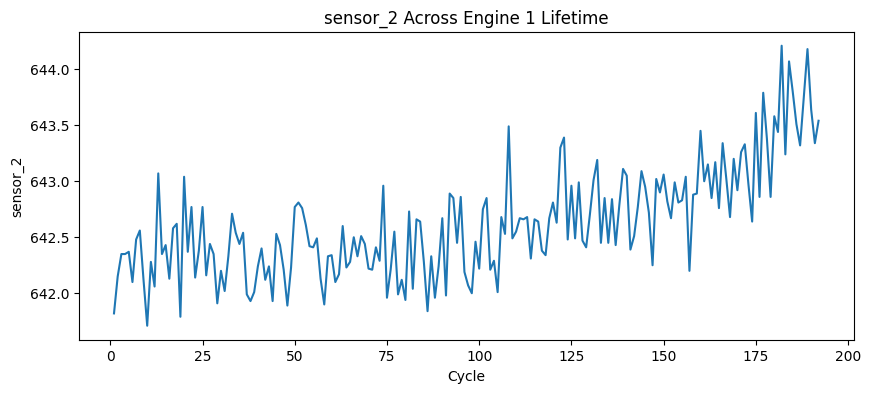

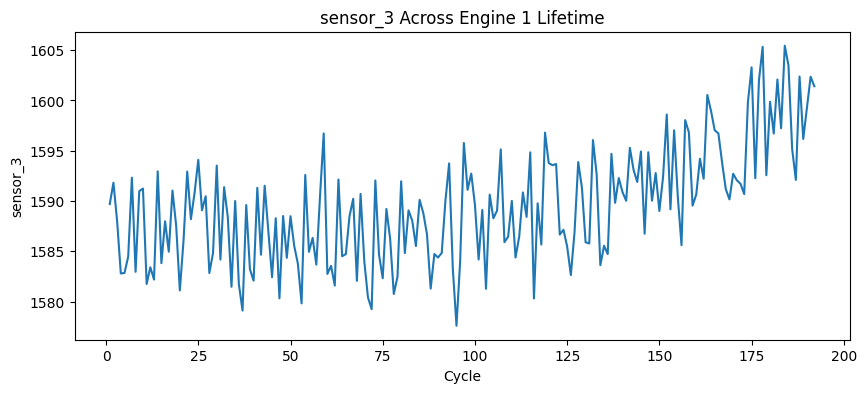

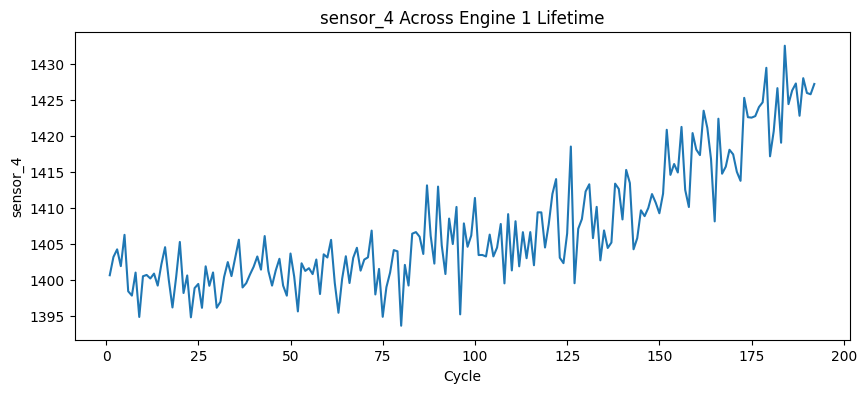

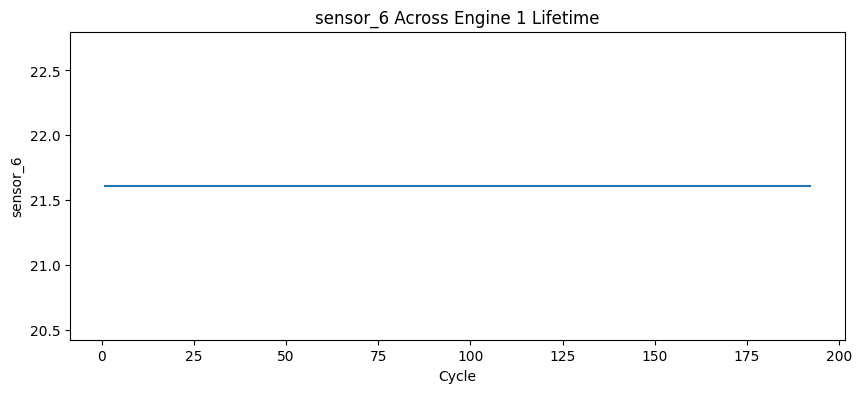

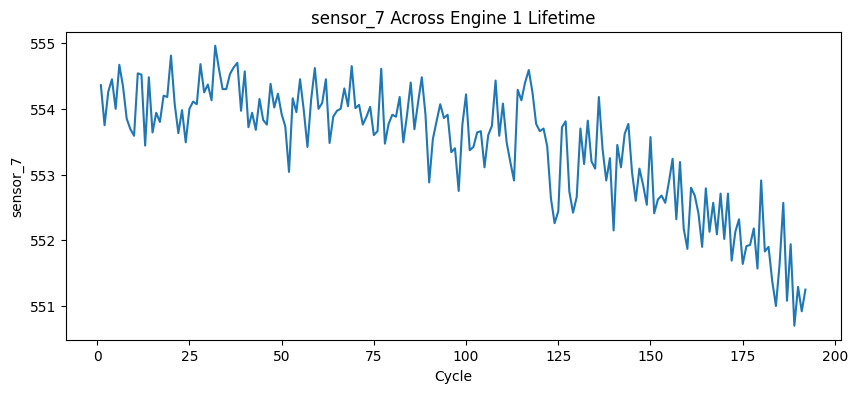

In [28]:
for sensor in sensor_columns[:5]:
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(
        engine_1["cycle"],
        engine_1[sensor]
    )
    
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.title(f"{sensor} Across Engine 1 Lifetime")
    
    plt.show()

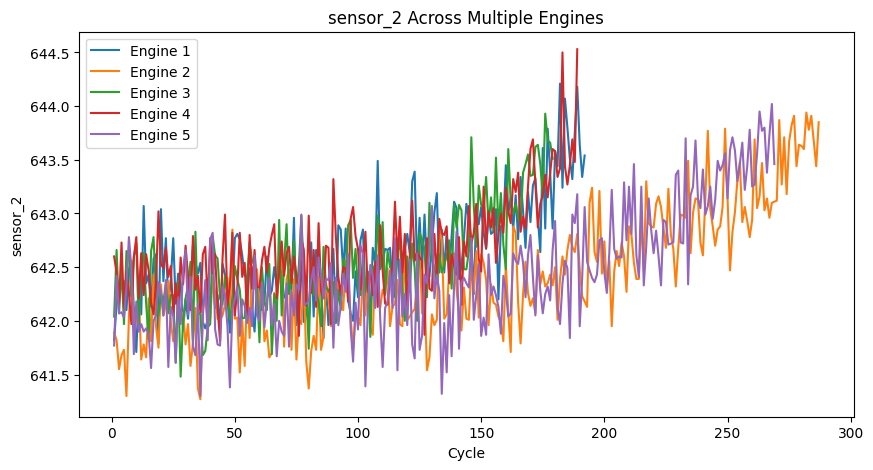

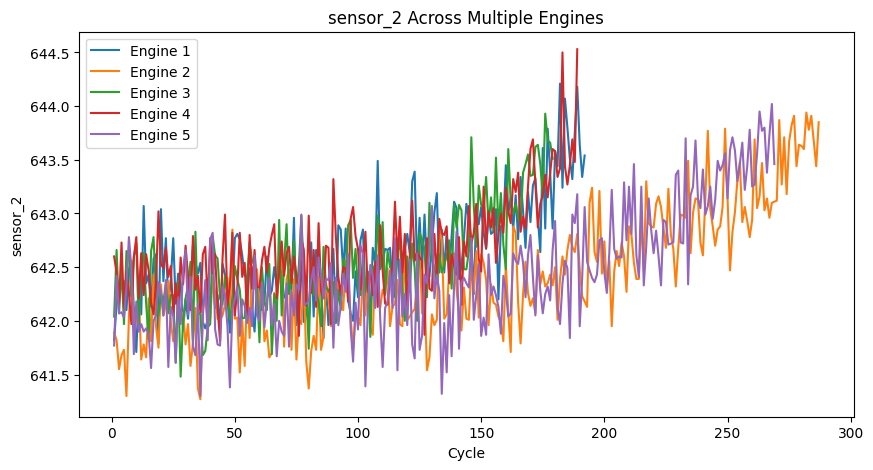

In [30]:
sensor = "sensor_2"
engine_ids = [1, 2, 3, 4, 5]

sensor = "sensor_2"

plt.figure(figsize=(10, 5))

for engine_id in engine_ids:
    engine_data = df[df["engine_id"] == engine_id]

    plt.plot(
        engine_data["cycle"],
        engine_data[sensor],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"{sensor} Across Multiple Engines")
plt.legend()

plt.show()
plt.figure(figsize=(10, 5))

for engine_id in engine_ids:
    engine_data = df[df["engine_id"] == engine_id]

    plt.plot(
        engine_data["cycle"],
        engine_data[sensor],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"{sensor} Across Multiple Engines")
plt.legend()

plt.show()

In [31]:
numeric_columns = df.select_dtypes(include=np.number).columns

In [34]:
correlation_with_rul = (
    df[numeric_columns]
    .corr()["RUL"]
    .sort_values()
)

In [35]:
correlation_with_rul.drop("RUL").abs().sort_values(ascending=False).head(15)

cycle        0.736241
sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2     0.606484
sensor_17    0.606154
sensor_3     0.584520
sensor_8     0.563968
sensor_13    0.562569
sensor_9     0.390102
max_cycle    0.363152
Name: RUL, dtype: float64

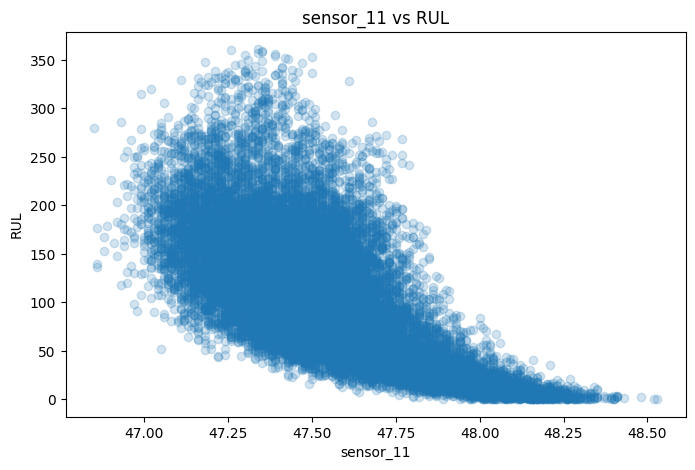

In [36]:
feature = "sensor_11"   # replace with your actual feature

plt.figure(figsize=(8, 5))

plt.scatter(
    df[feature],
    df["RUL"],
    alpha=0.2
)

plt.xlabel(feature)
plt.ylabel("RUL")
plt.title(f"{feature} vs RUL")

plt.show()

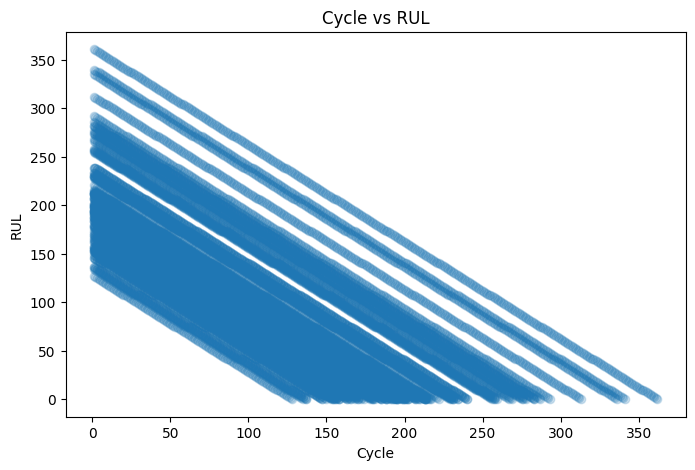

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["cycle"],
    df["RUL"],
    alpha=0.2
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("Cycle vs RUL")

plt.show()

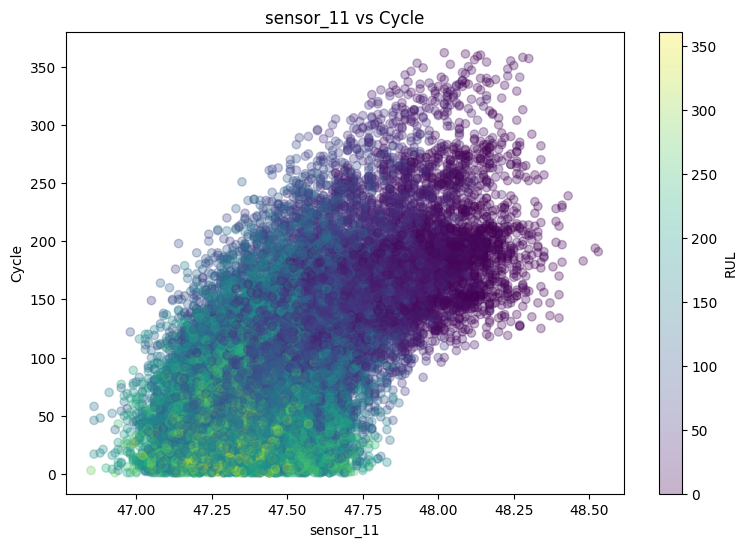

In [38]:
feature = "sensor_11"   # use one of your strongest features

plt.figure(figsize=(9, 6))

plt.scatter(
    df[feature],
    df["cycle"],
    c=df["RUL"],
    alpha=0.3
)

plt.xlabel(feature)
plt.ylabel("Cycle")
plt.title(f"{feature} vs Cycle")

plt.colorbar(label="RUL")

plt.show()